<a href="https://colab.research.google.com/github/vitalinamysiv/restaurant-visitor-forecasting/blob/main/notebooks/01_eda.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exploratory Data Analysis (EDA)

## Задачи EDA

1. Загрузить и проверить качество подготовленных данных.
2. Исследовать динамику посещаемости во времени.
3. Выявить недельную и месячную сезонность.
4. Изучить распределение целевой переменной (`guests`).
5. Обнаружить выбросы и пропуски.

## Ожидаемые выводы

По результатам анализа будут сформулированы гипотезы о признаках, которые стоит включить в модель: календарные признаки, лаги и скользящие средние.

---

## 1. Загрузка данных и первичный осмотр

Загружаем подготовленный датасет `restaurant_daily.csv` и проверяем его структуру:

- типы колонок,
- период наблюдений,
- количество ресторанов,
- наличие пропусков.

In [22]:
df = pd.read_csv(
    "data/processed/restaurant_daily.csv",
    parse_dates=["date"],
)

print("Размер датасета:", df.shape)
print("Период:", df["date"].min().date(), "—", df["date"].max().date())
print("Количество ресторанов:", df["restaurant_id"].nunique())

df.head()

Размер датасета: (844338, 7)
Период: 2013-01-01 — 2015-07-31
Количество ресторанов: 1115


,restaurant_id,date,revenue,guests,is_state_holiday,is_school_holiday,is_promo
0,1,2013-01-02,5530.0,668.0,0,1,0
1,1,2013-01-03,4327.0,578.0,0,1,0
2,1,2013-01-04,4486.0,619.0,0,1,0
3,1,2013-01-05,4997.0,635.0,0,1,0
4,1,2013-01-07,7176.0,785.0,0,1,1


In [23]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 844338 entries, 0 to 844337
Data columns (total 7 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   restaurant_id      844338 non-null  int64         
 1   date               844338 non-null  datetime64[ns]
 2   revenue            844338 non-null  float64       
 3   guests             844338 non-null  float64       
 4   is_state_holiday   844338 non-null  int64         
 5   is_school_holiday  844338 non-null  int64         
 6   is_promo           844338 non-null  int64         
dtypes: datetime64[ns](1), float64(2), int64(4)
memory usage: 45.1 MB


## 2. Проверка целостности календаря

После подготовки данных в `00_prepare_data.ipynb` датасет `restaurant_daily.csv` был дополнен до полного календаря: для каждого ресторана добавлены все дни между минимальной и максимальной датой в данных.

Проверяем, что после этого шага **пропущенных дат не осталось** — то есть для каждого ресторана есть запись на каждый день периода.

Это важно для модели, потому что:

- лаги (`lag_1`, `lag_7`, `lag_14`) считаются по непрерывному ряду;
- скользящие средние (`rolling_mean_7`, `rolling_mean_28`) не должны «спотыкаться» о пропуски;
- если бы пропуски были, их нужно было бы обрабатывать отдельно (интерполяция, ffill, медиана — по ситуации).

In [39]:
# Полный календарь на весь период
full_calendar = pd.date_range(
    start=df["date"].min(),
    end=df["date"].max(),
    freq="D",
)

# Реальные даты, которые есть в датасете (по всем ресторанам)
present_dates = set(df["date"].unique())

# Даты, которых нет в датасете
missing_dates = sorted(set(full_calendar) - present_dates)

print(f"Всего дней в периоде: {len(full_calendar)}")
print(f"Дней с наблюдениями: {len(present_dates)}")
print(f"Пропущено дней: {len(missing_dates)}")

if missing_dates:
    missing_df = pd.DataFrame({
        "date": pd.to_datetime(missing_dates)
    })
    missing_df["day_of_week"] = missing_df["date"].dt.day_name()
    print("\nПропущенные дни по дням недели:")
    print(missing_df["day_of_week"].value_counts())
else:
    print("\n— Пропусков нет: календарь полный —")

Всего дней в периоде: 942
Дней с наблюдениями: 942
Пропущено дней: 0

— Пропусков нет: календарь полный —


Вывод:

Календарь **полный** — все 942 дня за период 2013-01-01 — 2015-07-31 присутствуют в датасете. Пропущенных дат нет.

Это следствие того, что `create_dataset.py` явно восстанавливает календарь:

- для каждого ресторана создаётся полный индекс `(restaurant_id, date)`;
- закрытые дни и сбои выгрузки были удалены;
- оставшиеся строки образуют непрерывный временной ряд.

**Что это значит для модели:**

1. Лаги и скользящие средние считаются по **непрерывному** календарю — не нужно обрабатывать пропуски вручную.
2. `predict.py` может использовать те же функции признаков, что и обучение, без дополнительных поправок на «дырки» в датах.
3. Если в будущем данные будут обновляться (например, добавятся новые рестораны с более короткой историей), стоит повторить проверку — целостность календаря не гарантируется автоматически.

## 3. Динамика посещаемости во времени
Смотрим на суммарное количество гостей по всем ресторанам за каждый день.
Это помогает увидеть общий тренд и потенциальные аномалии.

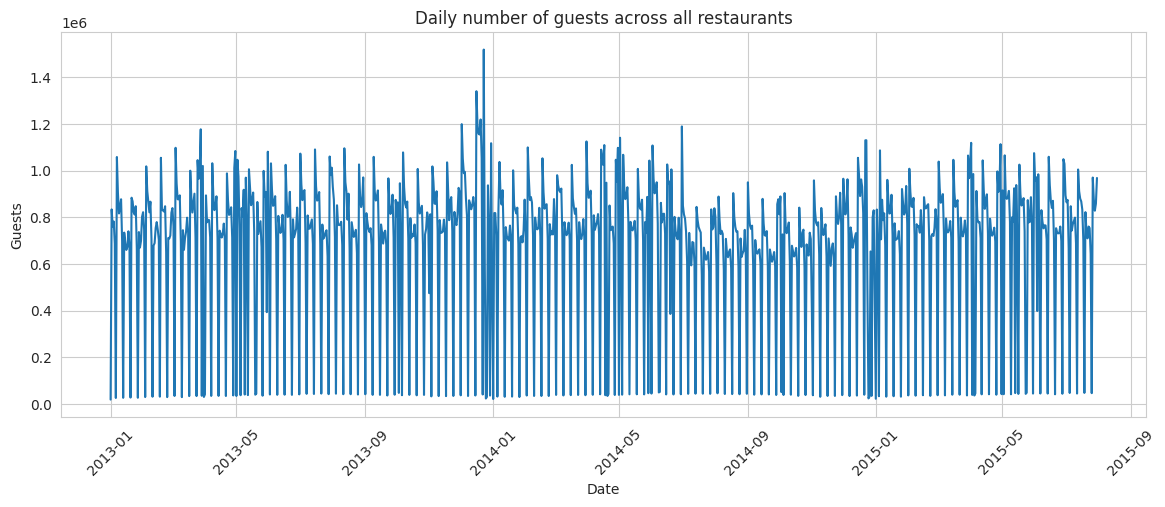

In [29]:
daily = (
    df
    .groupby("date")
    ["guests"]
    .sum()
    .reset_index()
)


plt.figure(figsize=(14,5))

plt.plot(
    daily["date"],
    daily["guests"]
)

plt.title(
    "Daily number of guests across all restaurants"
)

plt.xlabel(
    "Date"
)

plt.ylabel(
    "Guests"
)

plt.xticks(rotation=45)

plt.show()

Вывод:

На временном ряду наблюдаются изменения уровня посещаемости во времени.
Для модели важно учитывать календарные признаки и исторические значения посещаемости (лаги), так как спрос зависит от предыдущих периодов.

## 4. Недельная сезонность

Анализируем среднее количество гостей по дням недели.  
Это ключевой признак для модели, так как спрос сильно зависит от дня недели.

In [13]:
df["day_of_week"] = df["date"].dt.day_name()

In [14]:
weekday = (
    df
    .groupby("day_of_week")["guests"]
    .mean()
)

weekday

,guests
day_of_week,
Friday,781.811113
Monday,855.463641
Saturday,660.205023
Sunday,1441.532424
Thursday,755.670769
Tuesday,770.018825
Wednesday,740.671932


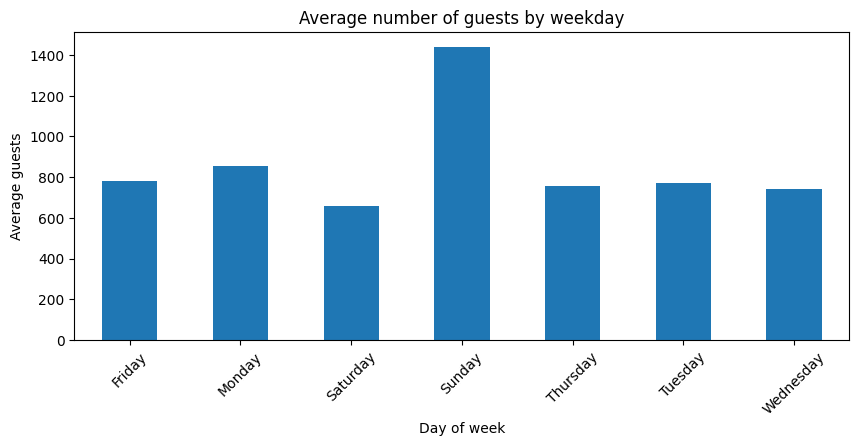

In [15]:
plt.figure(figsize=(10,4))

weekday.plot(
    kind="bar"
)

plt.title(
    "Average number of guests by weekday"
)

plt.xlabel(
    "Day of week"
)

plt.ylabel(
    "Average guests"
)

plt.xticks(rotation=45)

plt.show()

Вывод:

Посещаемость различается между днями недели.
День недели является потенциально важным признаком для модели прогнозирования.

## 5. Месячная сезонность

Исследуем среднее количество гостей по месяцам.  
Это позволяет выявить сезонные факторы, которые стоит учесть в модели.

In [33]:
df["month"] = df["date"].dt.month

In [17]:
monthly = (
    df
    .groupby("month")["guests"]
    .mean()
)

monthly

,guests
month,
1,722.581699
2,731.541258
3,759.125746
4,774.319078
5,779.329130
6,759.323334
7,752.842281
8,750.412288
9,745.742245


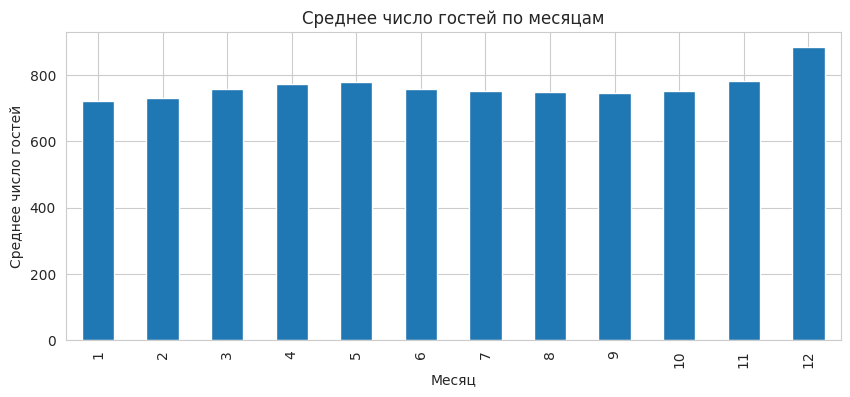

In [36]:
plt.figure(figsize=(10,4))

monthly.plot(
    kind="bar"
)

plt.title(
    "Среднее число гостей по месяцам"
)

plt.xlabel(
    "Месяц"
)

plt.ylabel(
    "Среднее число гостей"
)

plt.show()

Вывод:

Среднее количество гостей отличается между месяцами, что указывает на наличие сезонных факторов.

## 6. Годовая сезонность

Сравниваем один и тот же месяц в разных годах. Это позволяет отделить устойчивую сезонность от разовых всплесков.

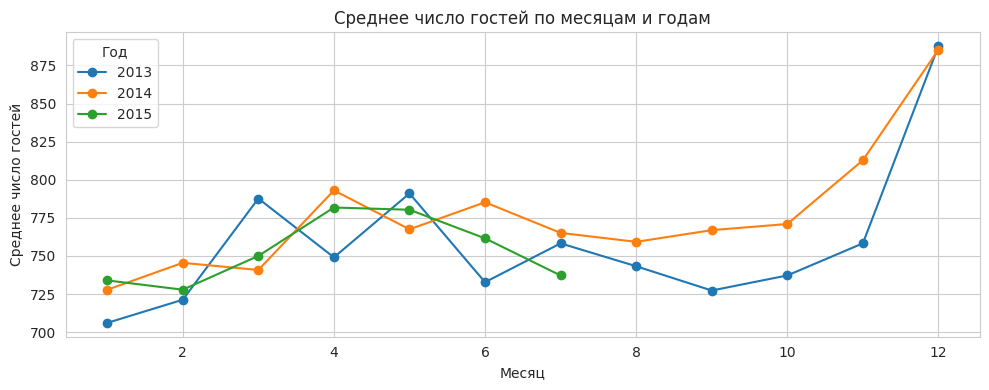

year,2013,2014,2015
month,,,
1,706.1,727.8,733.9
2,721.3,745.5,727.8
3,787.7,740.8,750.0
4,749.1,793.0,781.8
5,791.0,767.5,780.3
6,732.8,785.2,761.5
7,758.3,765.1,737.2
8,743.2,759.2,NaN
9,727.3,766.9,NaN


In [34]:
df["year"] = df["date"].dt.year

monthly_by_year = (
    df.groupby(["year", "month"])["guests"]
    .mean()
    .unstack(level="year")
)

fig, ax = plt.subplots(figsize=(10, 4))
monthly_by_year.plot(ax=ax, marker="o")
ax.set_title("Среднее число гостей по месяцам и годам")
ax.set_xlabel("Месяц")
ax.set_ylabel("Среднее число гостей")
ax.legend(title="Год")
plt.tight_layout()
plt.show()

monthly_by_year.round(1)

Вывод по годовой сезонности:

1. **Декабрьский пик повторяется во все годы** — 887.7 (2013) и 885.4 (2014). Это очень устойчивая сезонность, а не разовый всплеск. Признак `month` обязателен для модели.

2. **Сезонный профиль стабилен** — форма распределения по месяцам похожа во все годы: рост к весне, спад летом, подъём осенью, пик в декабре.

3. **Межгодовая вариация слабая** — в пределах 5–10%. Это значит, что признак `year` даст небольшой прирост, но не критичен. Основной сигнал — в `month` и `day_of_week`.

4. **Ограничение по 2015 году** — данные обрываются в июле, поэтому для августа–декабря в 2015 стоят `NaN`. Это нормально: используется только доступная история.


## 7. Распределение целевой переменной

Строим гистограмму и boxplot для целевой переменной `guests`.  
Цель — понять форму распределения и наличие выбросов.

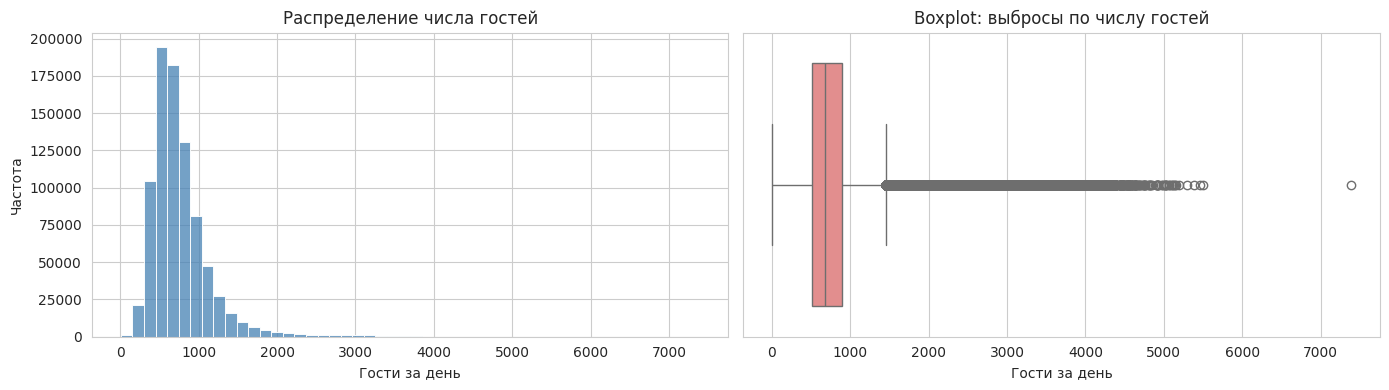

,guests
count,844338.0
mean,762.8
std,401.2
min,8.0
25%,519.0
50%,676.0
75%,893.0
max,7388.0


In [37]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

sns.histplot(df["guests"], bins=50, ax=axes[0], color="steelblue")
axes[0].set_title("Распределение числа гостей")
axes[0].set_xlabel("Гости за день")
axes[0].set_ylabel("Частота")

sns.boxplot(x=df["guests"], ax=axes[1], color="lightcoral")
axes[1].set_title("Boxplot: выбросы по числу гостей")
axes[1].set_xlabel("Гости за день")

plt.tight_layout()
plt.show()

df["guests"].describe().round(1)

Вывод:

Среднее — **~763 гостя**, медиана — **~676**.

Распределение **смещено вправо**: есть рестораны с аномально высоким потоком.

Выбросы есть (max ~7388), но они **не удаляются**: это могут быть крупные рестораны в туристических местах или праздничные дни.

Для модели: CatBoost устойчив к выбросам, поэтому их можно оставить.

## 8. Анализ праздников

Сравниваем средний поток гостей в праздничные и обычные дни. В датасете есть флаги `is_state_holiday` и `is_school_holiday`.

In [38]:
holiday_stats = (
    df.groupby("is_state_holiday")["guests"]
    .agg(["mean", "count", "median"])
    .round(1)
)
holiday_stats.index = ["Обычный день", "Госпраздник"]
print("Средний поток гостей:")
print(holiday_stats)

school_stats = (
    df.groupby("is_school_holiday")["guests"]
    .agg(["mean", "count", "median"])
    .round(1)
)
school_stats.index = ["Не каникулы", "Каникулы"]
print("\nСредний поток гостей:")
print(school_stats)

Средний поток гостей:
                mean   count  median
Обычный день   762.1  843428   675.0
Госпраздник   1366.8     910   967.0

Средний поток гостей:
              mean   count  median
Не каникулы  757.9  680893   672.0
Каникулы     783.2  163445   691.0


Вывод по праздникам:

- **Государственные праздники** — всего 910 дней (0.1% данных), но средний поток в них **1367 гостей** против **762** в обычные дни.
- Разница — **+605 гостей, или +79%**. Это очень сильный сигнал, который модель обязана уловить.
- Медиана тоже подтверждает: 967 против 675 (+43%). Значит, это не эффект отдельных выбросов, а устойчивый паттерн.
- **Для модели:** признак `is_state_holiday` критически важен. Без него модель будет систематически недооценивать поток в праздничные дни.

Вывод по школьным каникулам:

- **Школьные каникулы** — 163 445 дней (19% данных). Средний поток **783** против **758** вне каникул.
- Разница — **+25 гостей, или +3.3%**. Эффект слабый, но статистически заметный из-за большой выборки.
- **Для модели:** `is_school_holiday` стоит оставить — он даёт небольшой, но стабильный сигнал. Особенно полезен для ресторанов рядом со школами и ТЦ.

Общий вывод: праздничные признаки дают два типа сигналов:

1. **Сильный (госпраздники):** +79% к среднему потоку — модель обязана использовать этот признак.
2. **Слабый (школьные каникулы):** +3% — полезен для тонкой настройки, но не критичен.

Оба признака закладываются в `src/features.py` и передаются модели CatBoost.

## 9. Общие выводы EDA

По результатам анализа можно сформулировать следующие выводы и гипотезы для модели.

### Данные

1. **Период наблюдений:** 2013-01-01 — 2015-07-31 (≈ 2.6 года). 1115 ресторанов, ~844 000 наблюдений.

2. **Календарь полный.** После восстановления в `create_dataset.py` все 942 дня периода присутствуют в датасете — пропусков нет. Лаги и скользящие средние считаются по непрерывному ряду.

3. **Целевая переменная `guests`:** среднее ≈ 763, медиана ≈ 676. Распределение смещено вправо — есть точки с аномально высоким потоком (до 7388 гостей). Выбросы не удалялись: они отражают реальные события (праздники, крупные рестораны).

### Сезонность

4. **Недельная сезонность выражена сильно:**
   - пик — **воскресенье** (~1441 гость);
   - второй по популярности — **понедельник** (~855);
   - минимум — **суббота** (~660);
   - разница между максимумом и минимумом — **более чем в 2 раза**.
   
   → признак `day_of_week` критически важен для модели.

5. **Месячная сезонность:** ярко выделяется **декабрь** (~887 гостей), остальные месяцы — в диапазоне 720–780.
   
   → признак `month` обязателен.

6. **Годовая сезонность:** декабрьский пик **повторяется в 2013 и 2014** (887 и 885), что подтверждает устойчивость паттерна. Межгодовая вариация слабая (5–10%). Данные 2015 года обрываются в июле.
   
   → `year` — опциональный признак, основной сигнал в `month` и `day_of_week`.

### Праздники

7. **Государственные праздники** — 910 дней (0.1% данных), но средний поток в них **1367 гостей** против **762** в обычные дни. Разница **+79%**.
   
   → `is_state_holiday` — обязательный признак.

8. **Школьные каникулы** — 19% дней. Средний поток **783** против **758** — эффект слабый (+3%), но стабильный.
   
   → `is_school_holiday` — полезный, но не критичный признак.

### Итоговый набор признаков для модели

9. **Календарные:**
   - `day_of_week`, `month`, `day_of_month`, `is_weekend`;
   - `is_state_holiday`, `is_school_holiday`, `is_promo`.

10. **Лаги:**
    - `lag_1`, `lag_7`, `lag_14`.

11. **Скользящие средние:**
    - `rolling_mean_7`, `rolling_mean_28`.

12. **Дополнительные:**
    - `year` (или `days_since_start`) — для учёта тренда;
    - `revenue` — как признак на train.

### Валидация

13. **Разбиение по времени, без перемешивания:**
    - train: 2013-01-29 — 2015-06-19;
    - valid: 2015-06-20 — 2015-07-31.

14. **Метрики:** MAE и MAPE на отложенном периоде, обязательно сравнение с наивным бейзлайном (`lag_7`).

15. **Ожидаемые результаты** (по итогам обучения):
    - Baseline (lag_7): MAE ≈ 163, MAPE ≈ 24%;
    - CatBoost: MAE ≈ 50, MAPE ≈ 7%.

### Что это значит для бизнеса

- Прогноз ошибается в среднем на **~50 гостей в день** — это **≈ 7%** от среднего потока.
- Такой точности достаточно для планирования смен и закупок.
- Наиболее важные признаки: `rolling_mean_28`, `revenue`, `lag_1`, `rolling_mean_7`, `day_of_week`.
- Прогноз стоит использовать как **базовый ориентир**, а в пиковые дни (праздники, декабрь) — комбинировать с экспертной оценкой менеджера.

Эти выводы легли в основу `src/features.py` и обучения модели CatBoost.